In [6]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [11]:
import matplotlib.pyplot as plt

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn
import plotly

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)
print("Plotly:", plotly.__version__)

NumPy: 1.26.4
Pandas: 3.0.3
Matplotlib: 3.10.1
Seaborn: 0.13.2
Plotly: 6.9.0


In [13]:
!pip install --upgrade plotly seaborn pandas


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
df=pd.read_csv('kidney_disease.csv')

In [16]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [17]:
df.shape

(400, 26)

In [18]:
df.drop('id',axis=1,inplace=True)

In [19]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              348 non-null

In [21]:
df['packed_cell_volume']=pd.to_numeric(df['packed_cell_volume'],errors='coerce')


In [22]:
df['white_blood_cell_count']=pd.to_numeric(df['white_blood_cell_count'],errors='coerce')
df['red_blood_cell_count']=pd.to_numeric(df['red_blood_cell_count'],errors='coerce')

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              348 non-null

In [86]:
cat_col=[col for col in df.columns if df[col].dtype=="object"]
num_col=[col for col in df.columns if df[col].dtype!="object"]

In [90]:
cat_col

Index(['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
       'appetite', 'peda_edema', 'aanemia'],
      dtype='str')

In [89]:
cat_col=df.select_dtypes(include=['object','string']).columns
num_col=df.select_dtypes(include=['number']).columns

In [26]:
for col in cat_col:
    print(f"{col} have {df[col].unique()} values\n")

In [27]:
df['diabetes_mellitus'].replace(to_replace={' yes':'yes','\tno':'no','\tyes':'yes'},inplace=True)

0      yes
1       no
2      yes
3       no
4       no
      ... 
395     no
396     no
397     no
398     no
399     no
Name: diabetes_mellitus, Length: 400, dtype: str

In [28]:
df['diabetes_mellitus'].unique()

<ArrowStringArray>
['yes', 'no', ' yes', '\tno', '\tyes', nan]
Length: 6, dtype: str

In [29]:
df['coronary_artery_disease'].replace(to_replace='\tno',value='no',inplace=True)

0      no
1      no
2      no
3      no
4      no
       ..
395    no
396    no
397    no
398    no
399    no
Name: coronary_artery_disease, Length: 400, dtype: str

In [30]:
df['coronary_artery_disease'].unique()

<ArrowStringArray>
['no', 'yes', '\tno', nan]
Length: 4, dtype: str

In [31]:
df['class']=df['class'].replace(to_replace='ckd\t',value='ckd')

In [32]:
df['class'].unique()

<ArrowStringArray>
['ckd', 'notckd']
Length: 2, dtype: str

In [33]:
df['class']=df['class'].map({'ckd':0,'notckd':1})

Text(0, 0.5, 'frequency')

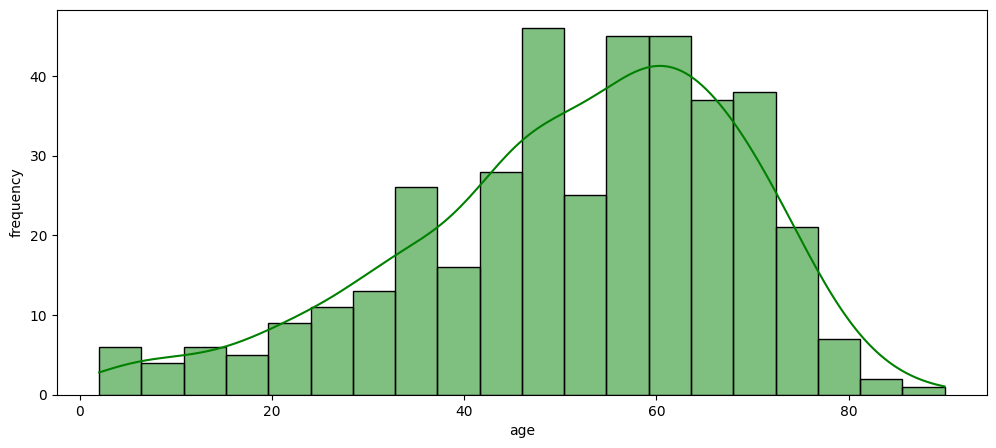

In [34]:
plt.figure(figsize=(12,5))
sns.histplot(df['age'].dropna(),color='g',bins=20,kde=True)

plt.xlabel('age')
plt.ylabel('frequency')


In [35]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='str')

<Axes: xlabel='hypertension', ylabel='count'>

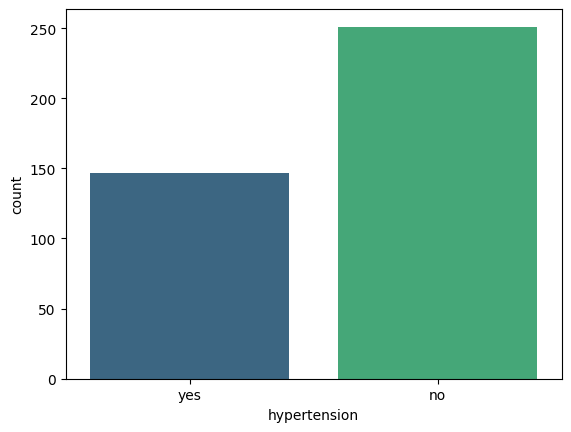

In [36]:
sns.countplot(x='hypertension',data=df,palette='viridis')

<Axes: xlabel='class', ylabel='blood_urea'>

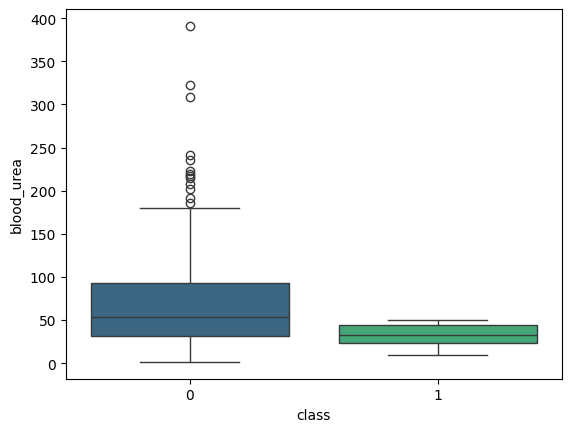

In [37]:
sns.boxplot(x='class',y='blood_urea',data=df,palette='viridis')

<Axes: xlabel='class', ylabel='serum_creatinine'>

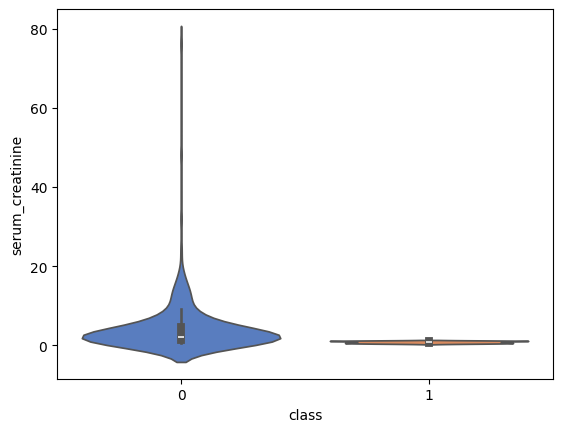

In [38]:
sns.violinplot(x='class',y='serum_creatinine',data=df,palette='muted')

<Axes: xlabel='aanemia', ylabel='count'>

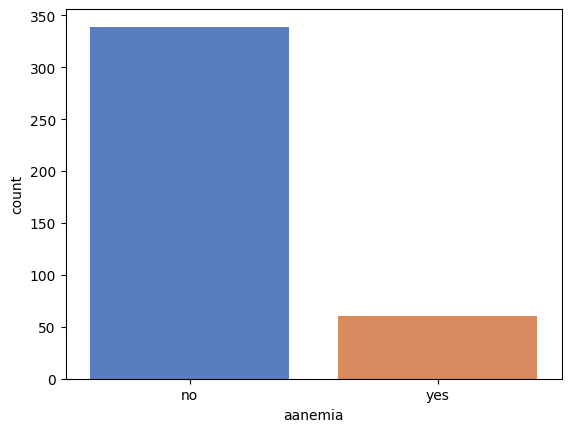

In [39]:
sns.countplot(x='aanemia',palette='muted',data=df)

In [40]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='str')

<Axes: >

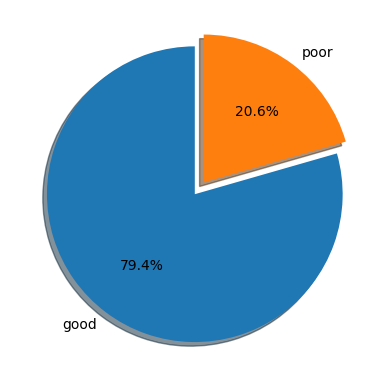

In [41]:
df['appetite'].value_counts().plot.pie(autopct='%1.1f%%',explode=(0,0.1),shadow=True,startangle=90)

<Axes: xlabel='pus_cell_clumps', ylabel='count'>

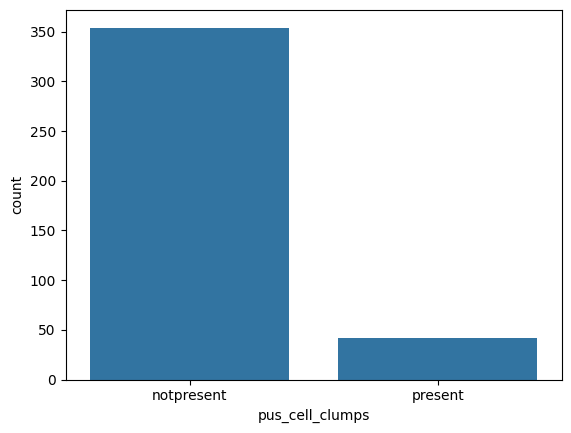

In [42]:
sns.countplot(x='pus_cell_clumps',data=df)

<Axes: xlabel='white_blood_cell_count', ylabel='Count'>

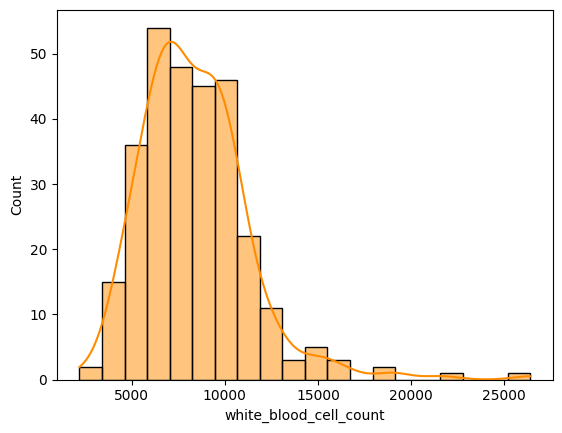

In [43]:
sns.histplot(x=df['white_blood_cell_count'].dropna(),data=df,bins=20,kde=True,color='darkorange')

<Axes: >

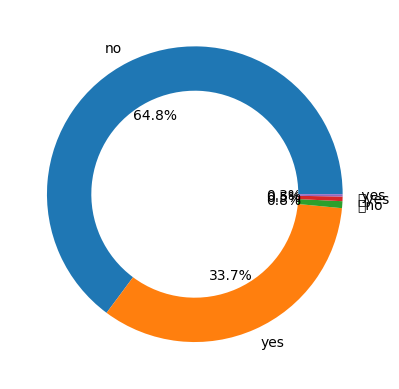

In [44]:
df['diabetes_mellitus'].value_counts().plot.pie(autopct='%1.1f%%',wedgeprops=dict(width=0.3))

<Axes: xlabel='coronary_artery_disease', ylabel='count'>

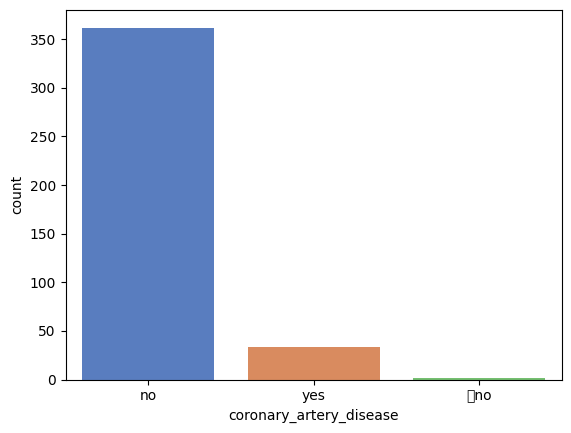

In [45]:
sns.countplot(x='coronary_artery_disease',data=df,palette='muted')

<Axes: xlabel='peda_edema', ylabel='count'>

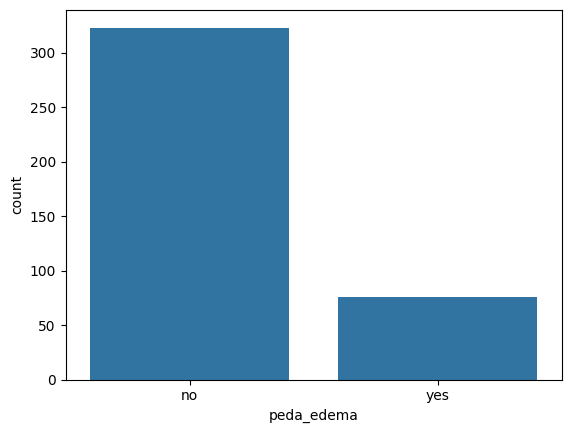

In [46]:
sns.countplot(x='peda_edema',data=df)

<Axes: xlabel='bacteria', ylabel='count'>

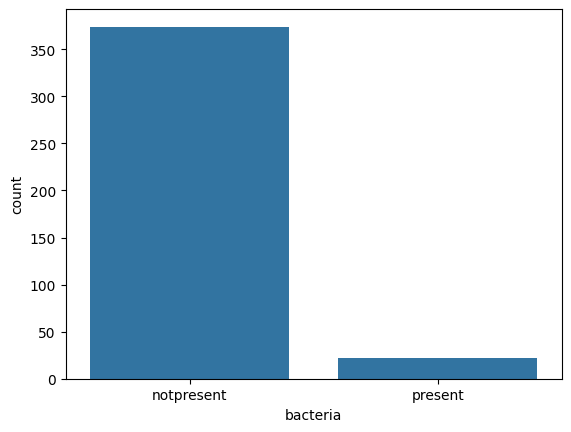

In [47]:
sns.countplot(x='bacteria',data=df)

In [48]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='str')

In [49]:
#bivarient analysis

<Axes: xlabel='age', ylabel='blood_pressure'>

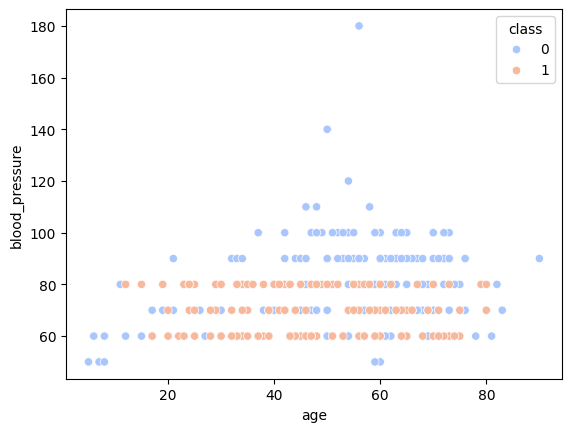

In [50]:
sns.scatterplot(x='age',y='blood_pressure',hue='class',data=df,palette='coolwarm')

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

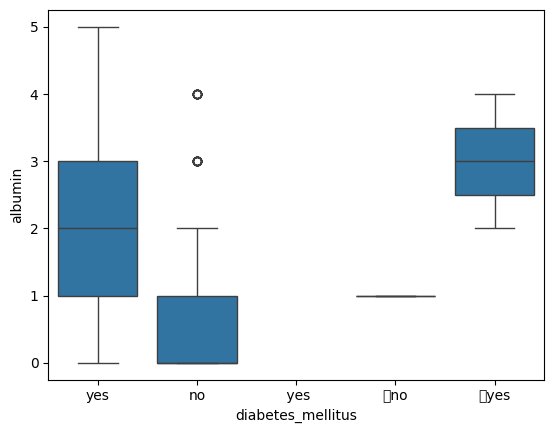

In [51]:
sns.boxplot(x='diabetes_mellitus',data=df,y='albumin')

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

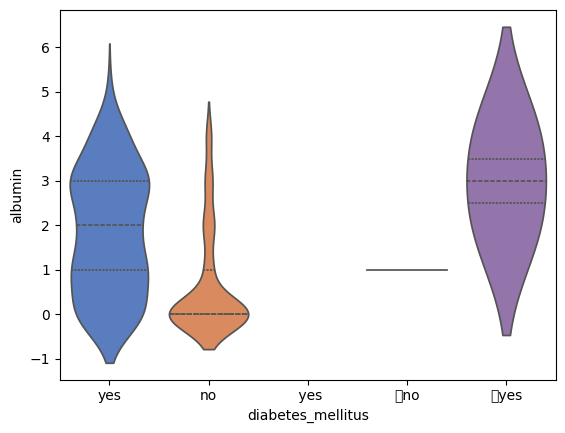

In [52]:
sns.violinplot(x='diabetes_mellitus',data=df,y='albumin',inner='quartile',palette='muted')

In [53]:
#stacked bar chart
diabeted_Hypertension=pd.crosstab(df['diabetes_mellitus'],df['hypertension'])

In [54]:
diabeted_Hypertension

hypertension,no,yes
diabetes_mellitus,,
\tno,3,0
\tyes,0,2
yes,0,1
no,217,41
yes,31,103


<Axes: xlabel='diabetes_mellitus'>

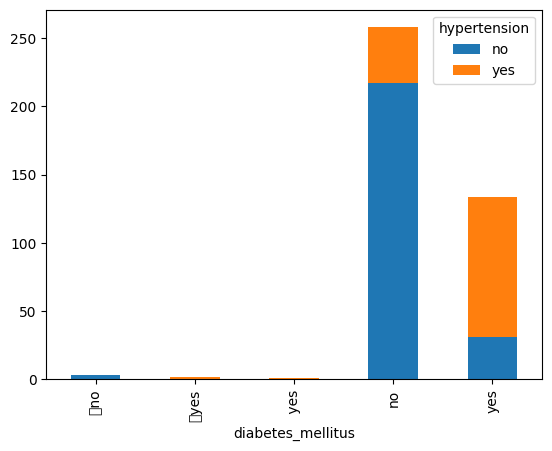

In [55]:
diabeted_Hypertension.plot(kind='bar',stacked=True)

In [91]:
num_col

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'class'],
      dtype='str')

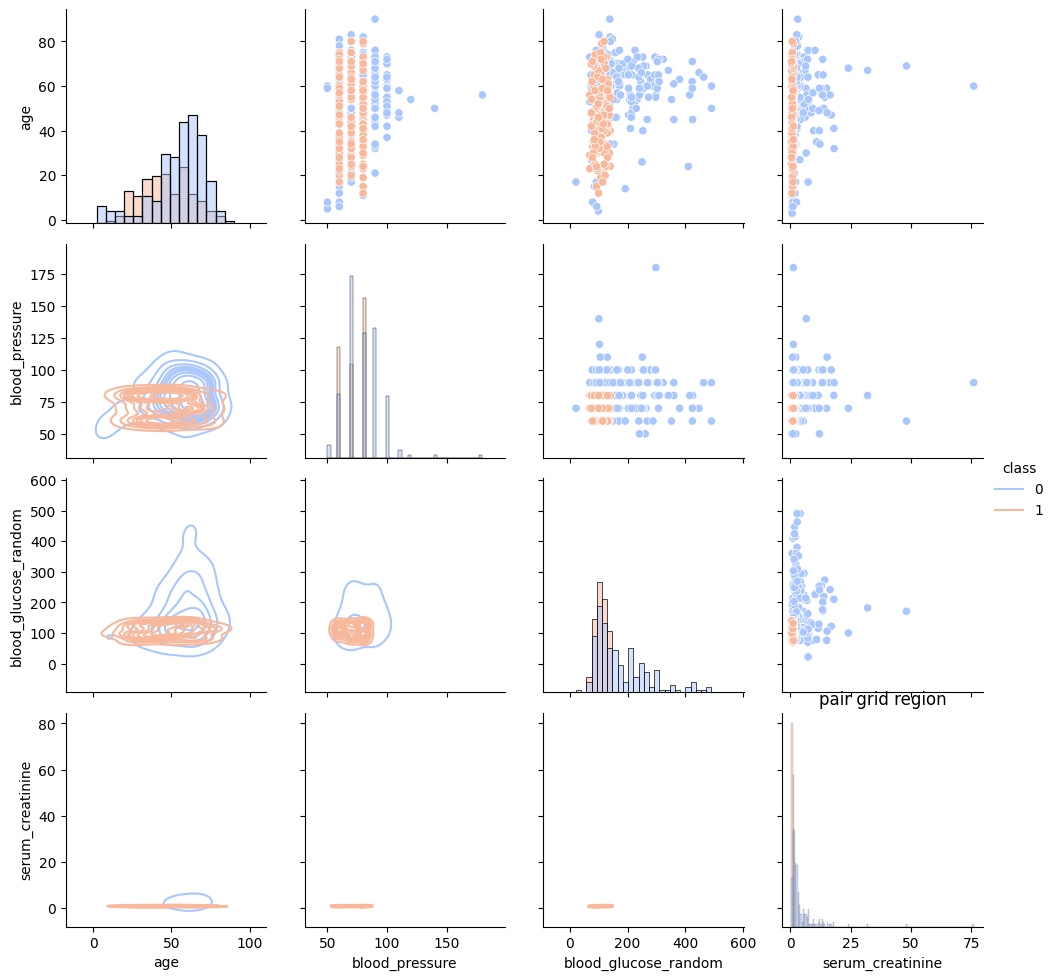

In [57]:
cols=['age','blood_pressure','blood_glucose_random','serum_creatinine','class']
g=sns.PairGrid(df[cols],hue='class',palette='coolwarm')
g.map_upper(sns.scatterplot)
g.map_diag(sns.histplot)
g.map_lower(sns.kdeplot,cmap='Blues_d')
g.add_legend()
plt.title('pair grid region')
plt.show()

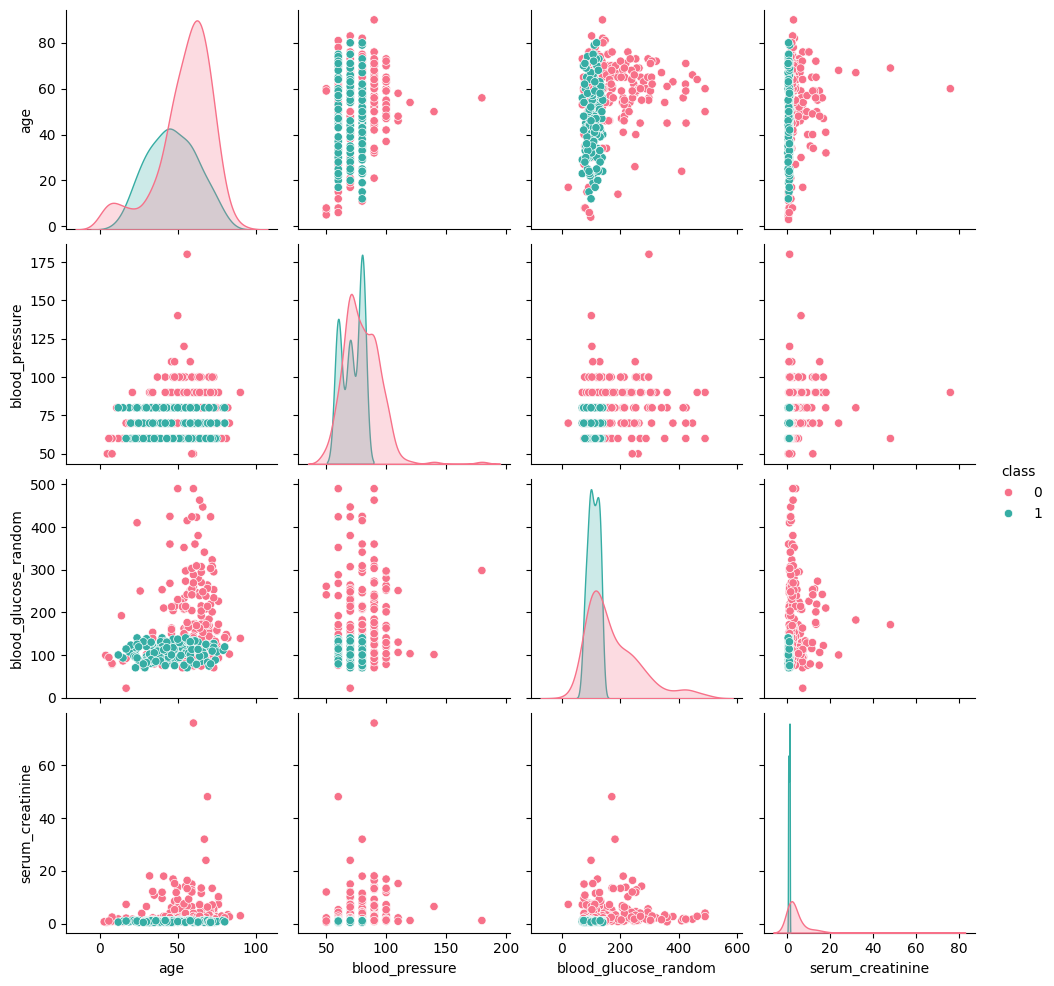

In [58]:
cols=['age','blood_pressure','blood_glucose_random','serum_creatinine','class']
sns.pairplot(df[cols],hue='class',palette='husl')

In [59]:
corr=df.corr(numeric_only=True)

<Axes: >

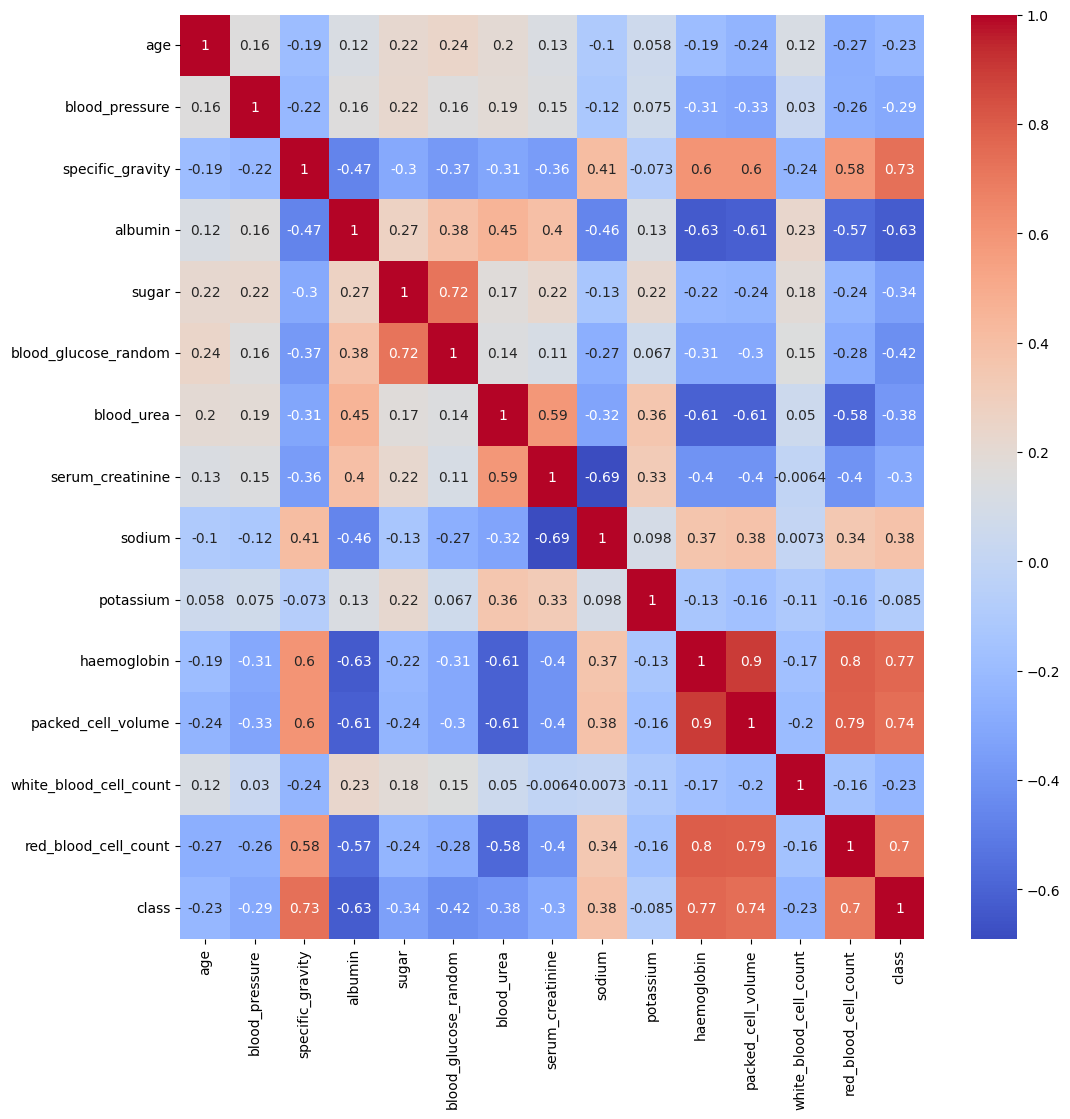

In [60]:
plt.figure(figsize=(12,12))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [61]:
cat_col

[]

<Axes: xlabel='diabetes_mellitus', ylabel='age'>

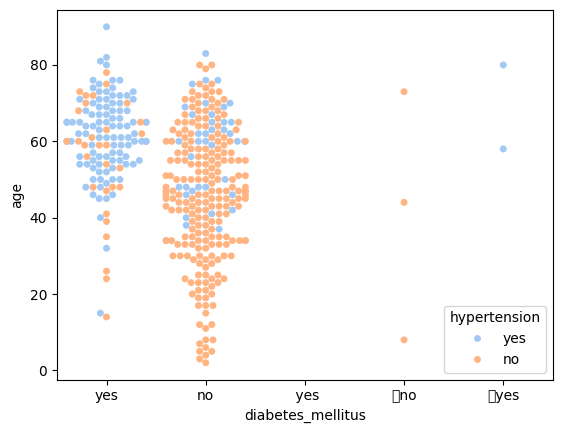

In [62]:
#bases on distribution of data
sns.swarmplot(x='diabetes_mellitus',y='age',hue='hypertension',palette='pastel',data=df)

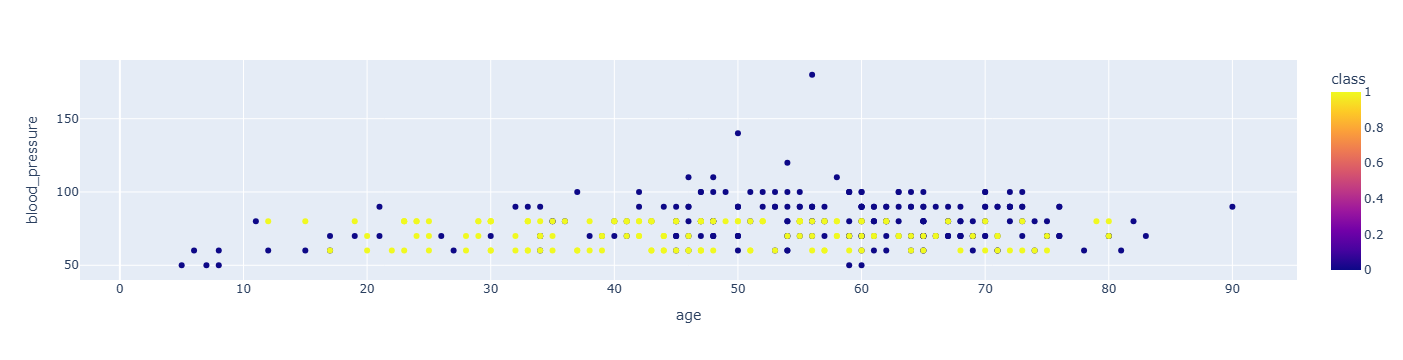

In [66]:
fig=px.scatter(df,x='age',y='blood_pressure',hover_data=['diabetes_mellitus','coronary_artery_disease'],color='class')
fig.show()

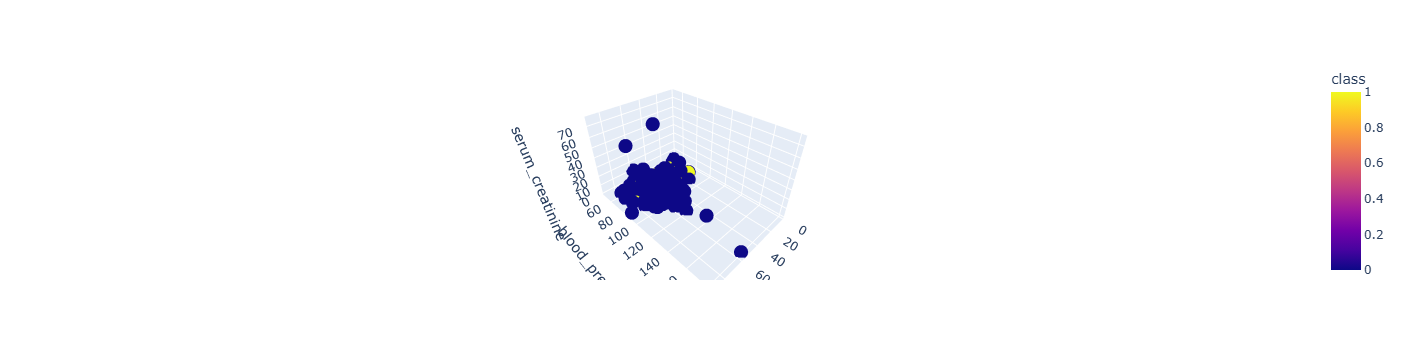

In [69]:
fig=px.scatter_3d(df,x='age',y='blood_pressure',z='serum_creatinine',color='class',title='3d scatter plot')
fig.show()

In [76]:
data_corr=df.corr(numeric_only=True)
data_corr.index

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'class'],
      dtype='str')

In [79]:
data_corr



,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,class
age,1.000000,0.159480,-0.191096,0.122091,0.220866,0.244992,0.196985,0.132531,-0.100046,0.058377,-0.192928,-0.242119,0.118339,-0.268896,-0.227268
blood_pressure,0.159480,1.000000,-0.218836,0.160689,0.222576,0.160193,0.188517,0.146222,-0.116422,0.075151,-0.306540,-0.326319,0.029753,-0.261936,-0.294077
specific_gravity,-0.191096,-0.218836,1.000000,-0.469760,-0.296234,-0.374710,-0.314295,-0.361473,0.412190,-0.072787,0.602582,0.603560,-0.236215,0.579476,0.732163
albumin,0.122091,0.160689,-0.469760,1.000000,0.269305,0.379464,0.453528,0.399198,-0.459896,0.129038,-0.634632,-0.611891,0.231989,-0.566437,-0.627090
sugar,0.220866,0.222576,-0.296234,0.269305,1.000000,0.717827,0.168583,0.223244,-0.131776,0.219450,-0.224775,-0.239189,0.184893,-0.237448,-0.344070
blood_glucose_random,0.244992,0.160193,-0.374710,0.379464,0.717827,1.000000,0.143322,0.114875,-0.267848,0.066966,-0.306189,-0.301385,0.150015,-0.281541,-0.419672
blood_urea,0.196985,0.188517,-0.314295,0.453528,0.168583,0.143322,1.000000,0.586368,-0.323054,0.357049,-0.610360,-0.607621,0.050462,-0.579087,-0.380605
serum_creatinine,0.132531,0.146222,-0.361473,0.399198,0.223244,0.114875,0.586368,1.000000,-0.690158,0.326107,-0.401670,-0.404193,-0.006390,-0.400852,-0.299969
sodium,-0.100046,-0.116422,0.412190,-0.459896,-0.131776,-0.267848,-0.323054,-0.690158,1.000000,0.097887,0.365183,0.376914,0.007277,0.344873,0.375674
potassium,0.058377,0.075151,-0.072787,0.129038,0.219450,0.066966,0.357049,0.326107,0.097887,1.000000,-0.133746,-0.163182,-0.105576,-0.158309,-0.084541


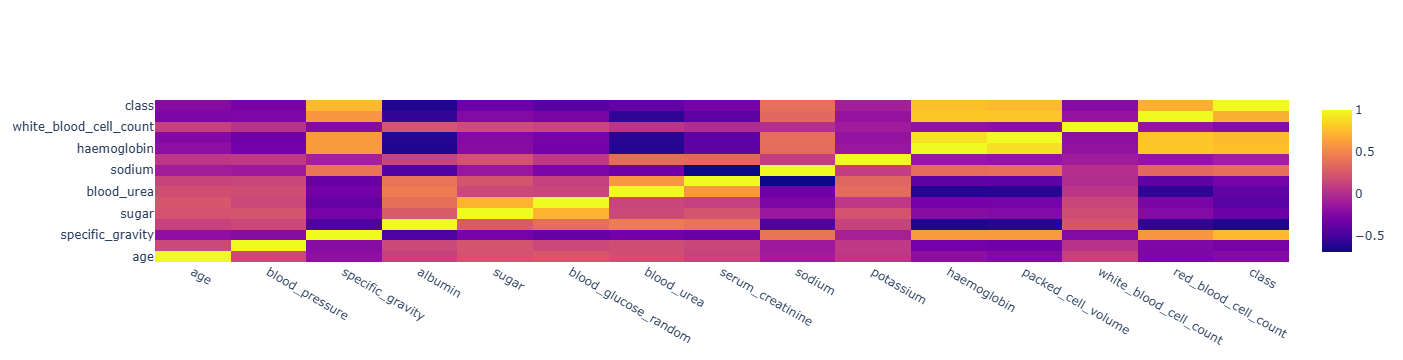

In [78]:
import  plotly.graph_objects as go
data_corr=df.corr(numeric_only=True)
fig=go.Figure(data=go.Heatmap(z=data_corr.values,x=data_corr.columns,y=data_corr.index))
fig.show()

In [95]:
#remove null values
median_values=df[num_col].median()

In [94]:
print(df[num_col].dtypes)

age                       float64
blood_pressure            float64
specific_gravity          float64
albumin                   float64
sugar                     float64
blood_glucose_random      float64
blood_urea                float64
serum_creatinine          float64
sodium                    float64
potassium                 float64
haemoglobin               float64
packed_cell_volume        float64
white_blood_cell_count    float64
red_blood_cell_count      float64
class                       int64
dtype: object


In [98]:
df[num_col]=df[num_col].fillna(median_values)

In [99]:
df[num_col].isna().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
class                     0
dtype: int64

In [102]:
mode_values=df.mode().iloc[0]
df[cat_col]=df[cat_col].fillna(mode_values)

In [103]:
df[cat_col].isna().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
dtype: int64

In [104]:
from sklearn.preprocessing import LabelEncoder


In [105]:
labelencoder=LabelEncoder()

In [106]:
for col in cat_col:
    df[col]=labelencoder.fit_transform(df[col])

In [107]:
df[cat_col]

,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
0,1,1,0,0,1,4,1,0,0,0
1,1,1,0,0,0,3,1,0,0,0
2,1,1,0,0,0,4,1,1,0,1
3,1,0,1,0,1,3,1,1,1,1
4,1,1,0,0,0,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,3,1,0,0,0
396,1,1,0,0,0,3,1,0,0,0
397,1,1,0,0,0,3,1,0,0,0
398,1,1,0,0,0,3,1,0,0,0
